In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('sales_data.csv')
print(df.head())
print(df.dtypes)

         Date     Product     Category  Sales  Quantity     Region  \
0  2024-01-05      Laptop  Electronics  85000         1    Karachi   
1  2024-01-07      Mobile  Electronics  45000         2     Lahore   
2  2024-01-10       Shirt     Clothing   2500         3  Islamabad   
3  2024-01-12  Headphones  Electronics   8500         1    Karachi   
4  2024-01-15       Jeans     Clothing   4500         2     Lahore   

   Customer_Age Customer_Gender  
0            25          Female  
1            30            Male  
2            22          Female  
3            28            Male  
4            35          Female  
Date                 str
Product              str
Category             str
Sales              int64
Quantity           int64
Region               str
Customer_Age       int64
Customer_Gender      str
dtype: object


In [3]:
# Prepare data for ML
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Category_encoded'] = le.fit_transform(df['Category'])
df['Region_encoded'] = le.fit_transform(df['Region'])
df['Gender_encoded'] = le.fit_transform(df['Customer_Gender'])

# Features and Target
X = df[['Category_encoded', 'Region_encoded', 'Quantity', 'Customer_Age', 'Gender_encoded']]
y = df['Sales']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (50, 5)
Target shape: (50,)


In [4]:
# Split data and train model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
r2 = r2_score(y_test, y_pred)
print("R2 Score:", round(r2, 2))
print("Model Accuracy:", str(round(r2*100, 2)) + "%")

R2 Score: 0.83
Model Accuracy: 83.29%


In [5]:
# Actual vs Predicted Graph
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()

NameError: name 'plt' is not defined

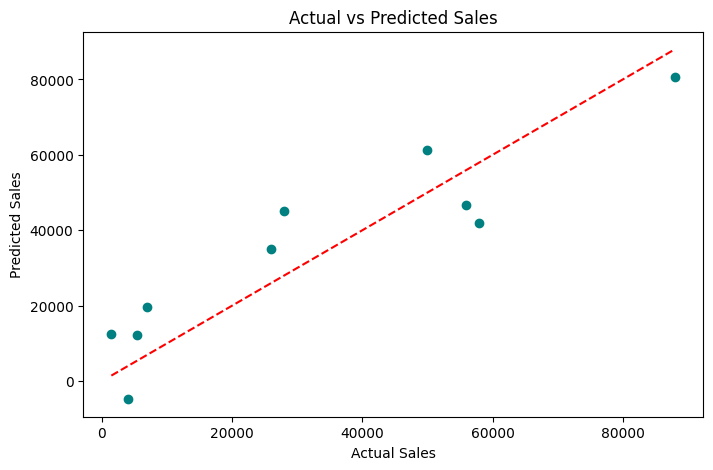

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Actual vs Predicted Graph
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()